In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 4.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
apps = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\play store\googleplaystore.csv")

reviews = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\play store\googleplaystore_user_reviews.csv") 

In [6]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [8]:
apps.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
--

In [10]:
apps.shape

(10841, 13)

In [11]:
reviews.shape 

(64295, 5)

In [12]:
apps.shape

reviews.shape

(64295, 5)

In [13]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [14]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [15]:
apps.drop_duplicates(inplace=True)

In [16]:
reviews.drop_duplicates(inplace=True)

In [17]:
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")

In [18]:
apps["Rating"].fillna(apps["Rating"].median(), inplace=True)

In [19]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")

In [20]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "")
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

In [21]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")

In [22]:
def convert_size(size):

    if pd.isnull(size):
        return np.nan

    if size == "Varies with device":
        return np.nan

    if "M" in size:
        return float(size.replace("M",""))

    elif "k" in size:
        return float(size.replace("k",""))/1024

    else:
        return np.nan

In [23]:
apps["Size"] = apps["Size"].apply(convert_size)

In [24]:
apps["Size"].fillna(apps["Size"].median(), inplace=True)

In [26]:
apps.loc[apps["Last Updated"] == "1.0.19"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,13.0,NaN,0,NaN,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [27]:
apps["Last Updated"].sample(10)

3929        June 11, 2018
5187        July 31, 2018
6118    February 22, 2016
4831        June 22, 2018
3648        July 11, 2018
609          July 9, 2018
8359       March 26, 2018
6119      October 4, 2015
5692         July 5, 2018
2423       August 4, 2018
Name: Last Updated, dtype: object

In [28]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          10358 non-null  float64
 3   Reviews         10357 non-null  float64
 4   Size            10358 non-null  float64
 5   Installs        10357 non-null  float64
 6   Type            10357 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.1+ MB


In [29]:
apps["Last Updated"] = pd.to_datetime(apps["Last Updated"], errors="coerce")

In [30]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10358 non-null  object        
 1   Category        10358 non-null  object        
 2   Rating          10358 non-null  float64       
 3   Reviews         10357 non-null  float64       
 4   Size            10358 non-null  float64       
 5   Installs        10357 non-null  float64       
 6   Type            10357 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10358 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11  Current Ver     10350 non-null  object        
 12  Android Ver     10355 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 1.1+ MB


In [31]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           1
Size              0
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      1
Current Ver       8
Android Ver       3
dtype: int64

In [32]:
apps["Reviews"].fillna(apps["Reviews"].median(), inplace=True)
apps["Installs"].fillna(apps["Installs"].median(), inplace=True)
apps["Price"].fillna(0, inplace=True)

In [33]:
apps["Type"].fillna(apps["Type"].mode()[0], inplace=True)
apps["Content Rating"].fillna(apps["Content Rating"].mode()[0], inplace=True)
apps["Current Ver"].fillna("Unknown", inplace=True)
apps["Android Ver"].fillna("Unknown", inplace=True)

In [34]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      1
Current Ver       0
Android Ver       0
dtype: int64

In [35]:
apps["Last Updated"].fillna(apps["Last Updated"].mode()[0], inplace=True)

In [36]:
apps.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

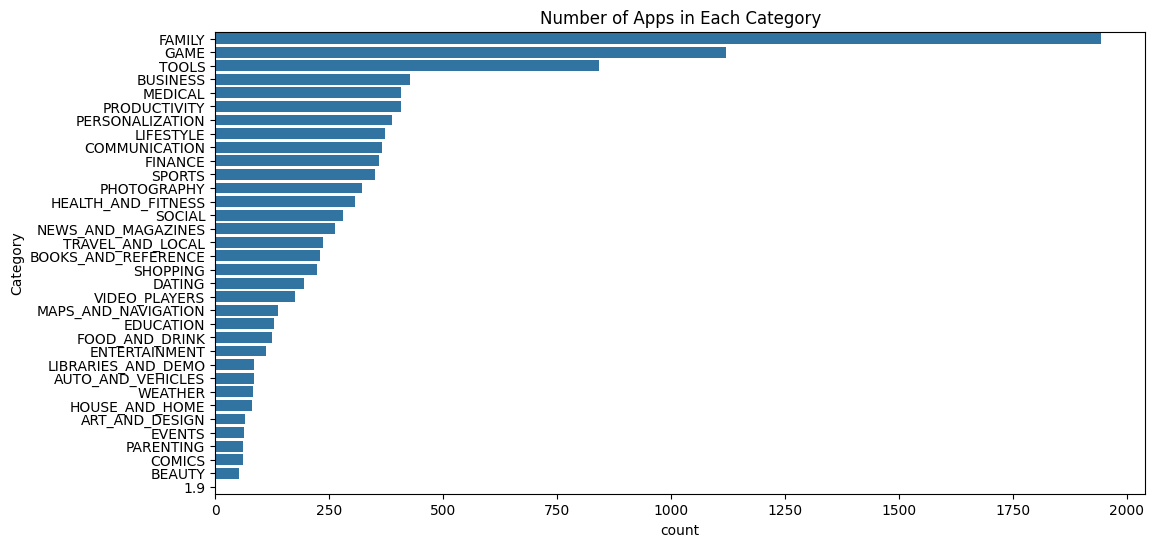

In [37]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=apps,
    y="Category",
    order=apps["Category"].value_counts().index
)

plt.title("Number of Apps in Each Category")

plt.show()

In [38]:
apps["Category"].value_counts().head(10)

Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

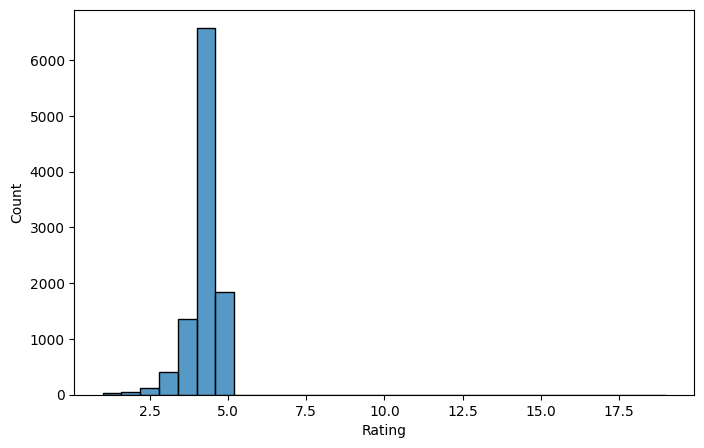

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(apps["Rating"], bins=30)

plt.show()

In [40]:
avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

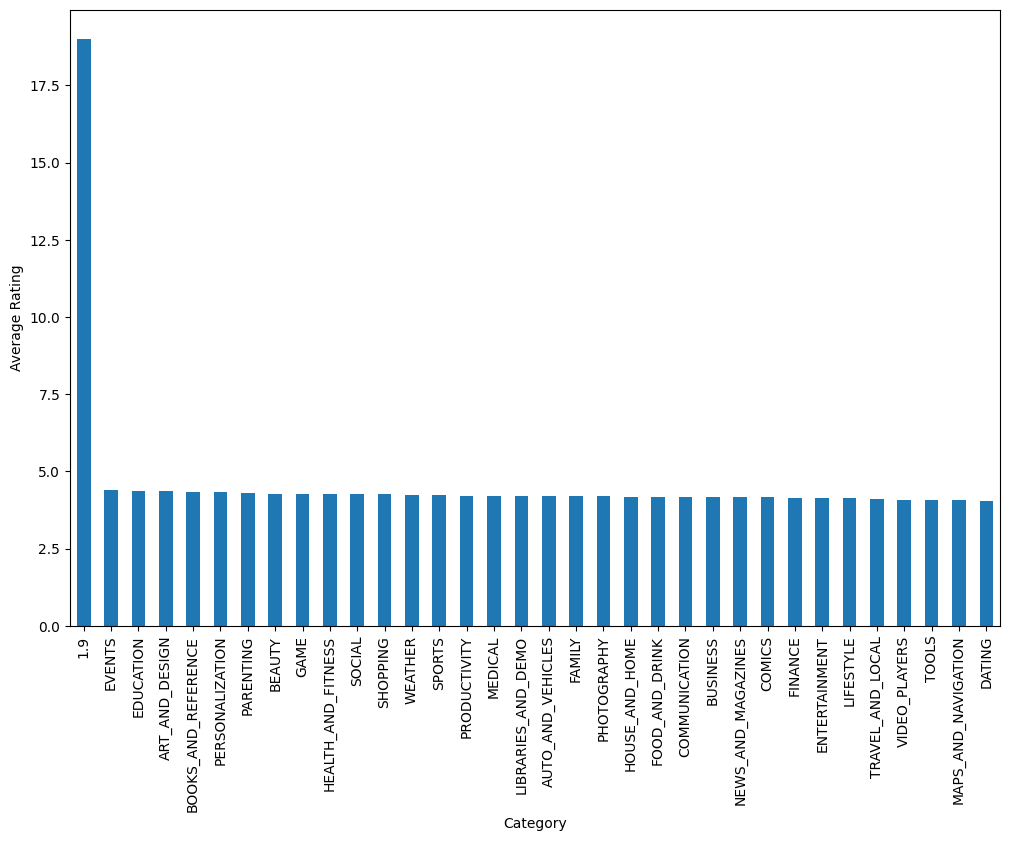

In [41]:
plt.figure(figsize=(12,8))

avg_rating.plot(kind="bar")

plt.ylabel("Average Rating")

plt.show()

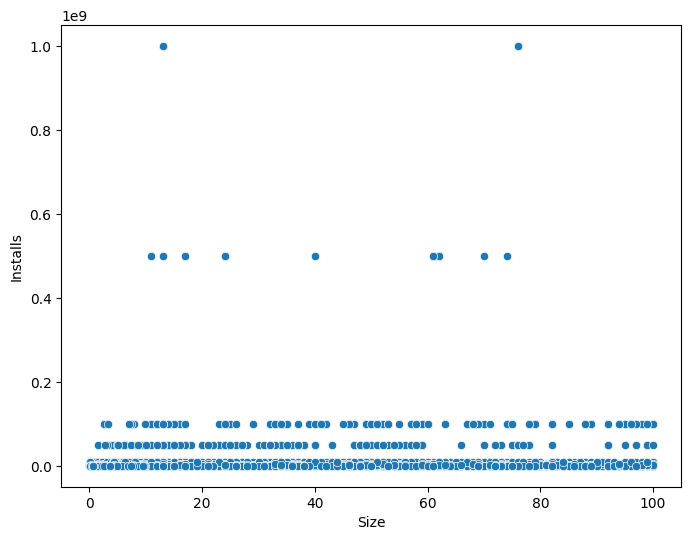

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=apps,
    x="Size",
    y="Installs"
)

plt.show()

In [43]:
apps[["Size","Installs"]].corr()

,Size,Installs
Size,1.000000,0.050127
Installs,0.050127,1.000000


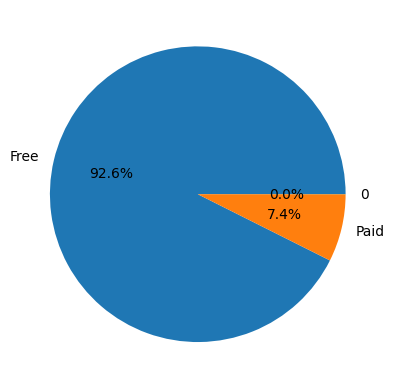

In [44]:
apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

In [45]:
paid = apps[apps["Type"]=="Paid"]

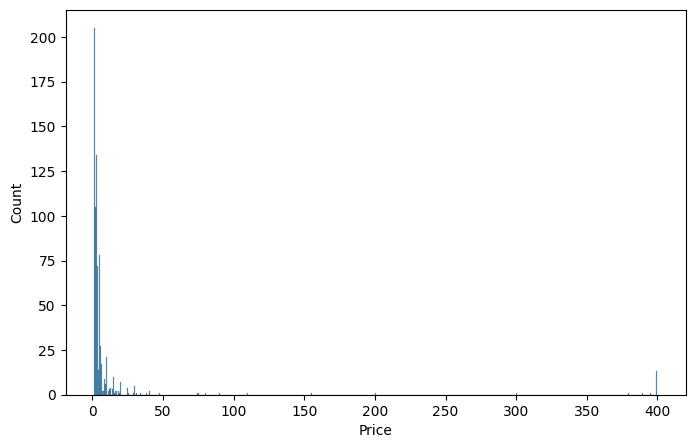

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(paid["Price"])

plt.show()

In [47]:
apps["Estimated Revenue"] = apps["Price"] * apps["Installs"]

In [48]:
revenue = (
    apps.groupby("Category")["Estimated Revenue"]
    .sum()
    .sort_values(ascending=False)
)

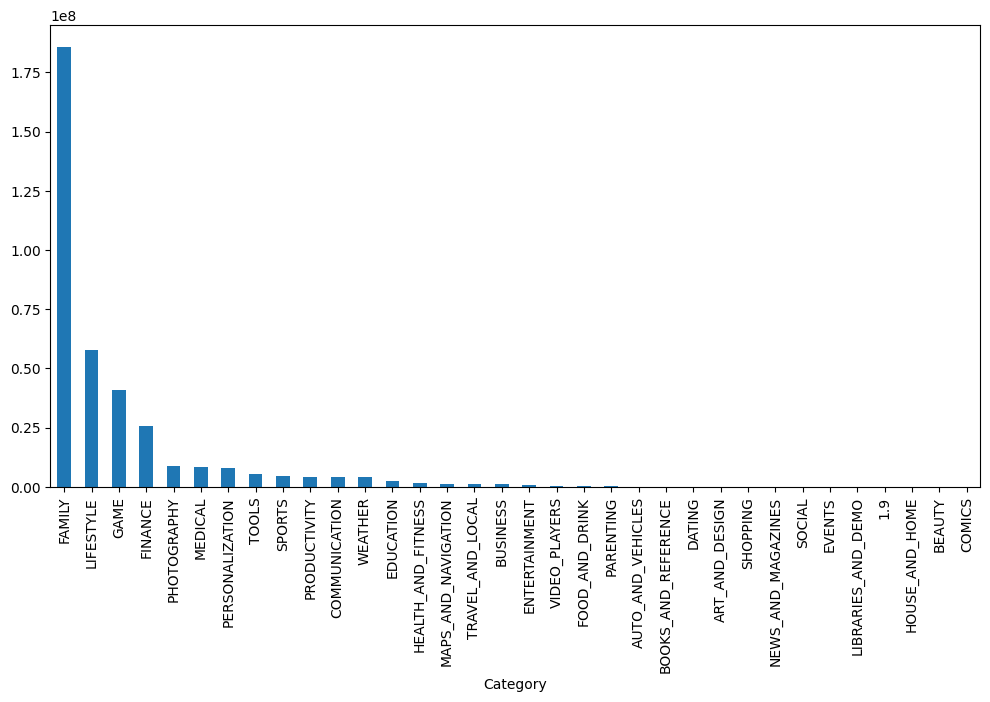

In [49]:
plt.figure(figsize=(12,6))

revenue.plot(kind="bar")

plt.show()

In [50]:
reviews = reviews.dropna(subset=["Translated_Review"])

In [51]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [52]:
reviews["Predicted_Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)

In [53]:
reviews["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64

In [54]:
merged = pd.merge(
    apps,
    reviews,
    on="App",
    how="inner"
)

In [55]:
sentiment_category = pd.crosstab(
    merged["Category"],
    merged["Predicted_Sentiment"]
)

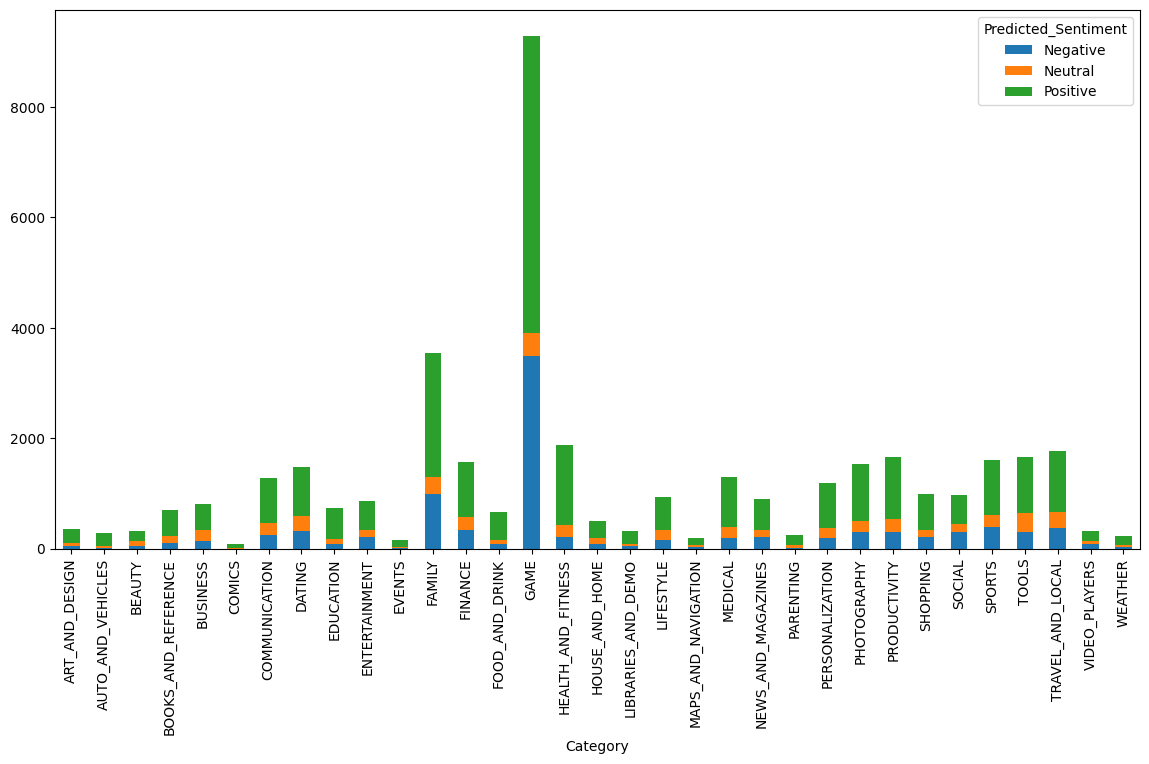

In [56]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.show()

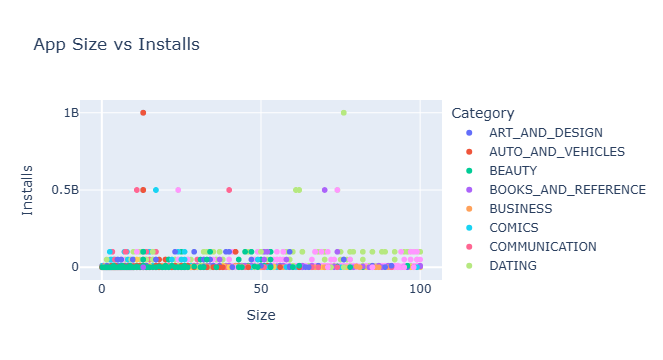

In [57]:
fig = px.scatter(
    apps,
    x="Size",
    y="Installs",
    color="Category",
    hover_name="App",
    title="App Size vs Installs"
)

fig.show()

Insight 1
Games, Family, and Tools categories have the highest number of apps, 
making them highly competitive.

Insight 2
Most apps are free, while paid apps represent only a small portion 
of the Play Store.

Insight 3
Apps with higher user ratings generally receive more installs, and 
positive user sentiment is associated with well rated apps.